# Step 2 비선형 상태 추정: EKF & UKF

## 0. 서론: Linear가 아닌 상황이라면?

Step 1에서 우리는 선형 칼만 필터(LKF)를 통해 "가우시안 잡음이 있는 선형 시스템"에서 최적의 추정값을 얻는 법을 배웠습니다. LKF의 세계에서는 시스템의 변화가 행렬의 곱셈($x_k = F x_{k-1}$) 하나로 깔끔하게 표현되었습니다.

하지만 우리가 다루는 로켓은 그렇지 않습니다.
$$ \text{Drag} \propto v^2, \quad \text{Air Density} \propto e^{-h} $$
항력은 속도의 제곱에 비례하고, 공기 밀도는 고도에 따라 지수적으로 변합니다. 이러한 **비선형(Nonlinear)** 시스템에서는 단순히 행렬 하나를 곱하는 것으로 다음 상태를 예측할 수 없습니다.

이 노트북에서는 비선형 문제를 해결하는 두 가지 거인, EKF(Extended Kalman Filter)와 UKF(Unscented Kalman Filter)를 구현하고, Step 1.5에서 생성한 시뮬레이션 데이터를 이용해 그 성능을 비교 검증합니다.

---

## 1. 이론적 배경 (Theoretical Background)

### 1.1 시스템 모델링: 로켓의 비선형 동역학

우리의 로켓은 1차원 수직 상승 운동을 한다고 가정할 때, 다음 상태 방정식(State Equation)을 따릅니다.

$$
\mathbf{x}_k = \begin{bmatrix} z_k \\ v_k \end{bmatrix} = f(\mathbf{x}_{k-1}, u_k) + \mathbf{w}_{k-1}
$$

구체적인 물리 모델은 다음과 같습니다 (오일러 적분):

1.  **고도 ($z$):** $z_k = z_{k-1} + v_{k-1} \Delta t$
2.  **속도 ($v$):** $v_k = v_{k-1} + \left( \frac{T - D(v, z)}{m} - g \right) \Delta t$

여기서 항력 $D(v, z) = \frac{1}{2} \rho(z) v^2 C_d A$ 항이 시스템을 강력한 **비선형**으로 만듭니다.

---

### 1.2 EKF: "곡선을 직선으로 펴보자" (Linearization)

EKF는 가장 직관적인 접근법을 취합니다. "비선형 함수가 복잡하니, 아주 짧은 구간에서 직선(선형)이라고 가정한다"는 것입니다. 즉 수학적으로 테일러 급수 전개(Taylor Series Expansion)를 매 스텝마다 수행합니다.

$$ f(x) \approx f(\hat{x}) + \mathbf{F} (x - \hat{x}) $$

여기서 기울기 행렬 $\mathbf{F}$가 바로 자코비안(Jacobian)입니다.

$$ \mathbf{F}_k = \frac{\partial f}{\partial x} \Big|_{\hat{x}_{k-1}} = \begin{bmatrix} 1 & \Delta t \\ 0 & 1 - \frac{\rho C_d A |v| \Delta t}{m} \end{bmatrix} $$

*   **장점:** 개념이 단순하고 연산량이 적습니다.
*   **한계:** 1차 미분(기울기)만 고려하고 2차 이상(곡률)을 무시하므로, 비선형성이 심한 구간(예: 천음속 돌파, 급격한 기동)에서는 오차가 누적되어 필터가 발산할 수 있습니다.

---

### 1.3 UKF: "함수 대신 확률분포를 근사하자" (Unscented Transform)

UKF의 창시자 Uhlmann은 UKF의 철학을 다음과 같이 설명했다.

> *"임의의 비선형 함수를 근사하는 것보다, 가우시안 확률 분포를 근사하는 것이 훨씬 쉽다."*

UKF는 미분(Jacobian)을 하지 않습니다. 대신 Unscented Transformation (UT)이라는 기법을 사용합니다.

#### 1.3.1 UT의 직관: 데이터의 압축과 해제
UT는 확률 분포를 처리하는 과정을 다음과 같이 수행합니다.

1.  **압축 (Sigma Points):** 무한히 많은 점으로 이루어진 확률 분포를, 그 분포의 평균과 분산을 완벽하게 대변하는 소수의 시그마 포인트($\chi$)로 압축합니다. ($n$차원일 때 $2n+1$개)
2.  **전송 (Propagation):** 이 점들을 비선형 함수 $f(\cdot)$에 직접 통과시킵니다. ($\mathcal{Y} = f(\chi)$)
3.  **복원 (Reconstruction):** 변환된 점들을 다시 가중 합산(Weighted Sum)하여 새로운 평균과 공분산을 계산합니다.

이 방식은 수학적으로 **테일러 급수의 2차 항(Hessian)까지의 정확도를 자동으로 확보**합니다. 미분을 한 번도 하지 않았음에도 EKF보다 더 정교한 결과를 내는 비결입니다.

#### 1.3.2 Scaled UT 파라미터 (Wan & van der Merwe)
시그마 포인트를 어떻게 뽑을지 결정하는 파라미터들입니다.

*   $\alpha$ (Alpha): 점들이 평균 주변에 얼마나 모여 있을지 결정합니다. 로켓처럼 비선형성이 심하면 작게($10^{-3}$) 설정하여 국소적인 특성을 봅니다.
*   $\kappa$ (Kappa): 차원 보정 상수로 보통 0을 사용합니다.
*   $\beta$ (Beta): 분포의 모양(Kurtosis)을 보정합니다. 가우시안 분포의 경우 $\beta=2$가 최적임이 증명되어 있습니다.

---

### 1.4 데이터 융합의 마법: $P_{xz}$와 $P_{zz}$

칼만 필터의 핵심은 예측값과 측정값을 섞는 비율인 **칼만 이득($K$)**을 구하는 것입니다.
$$ K = P_{xz} P_{zz}^{-1} $$

LKF나 EKF는 이를 수식(행렬 곱)으로 계산하지만, UKF는 이를 **통계적**으로 찾아냅니다.

*   **$P_{zz}$ (Innovation Covariance):** 시그마 포인트들이 예측한 측정값들이 얼마나 퍼져있는가? (불확실성)
*   **$P_{xz}$ (Cross Covariance):** 상태 변수($x$)가 변할 때 측정값($z$)이 얼마나 민감하게 같이 변하는가? (상관관계)

UKF는 시그마 포인트들의 움직임을 관찰함으로써, **미분 없이도 변수 간의 인과관계를 스스로 학습**하여 최적의 보정 비율을 찾아냅니다.

---

### 1.5 실전 구현을 위한 수치적 안전장치

이론적으로 공분산 행렬 $P$는 항상 **양의 준정부호(Positive Semi-Definite, PSD)**여야 합니다. 하지만 컴퓨터의 부동 소수점 연산 오차로 인해 이 성질이 깨지면 필터가 멈출 수 있습니다.

1.  **EKF의 해법 (Joseph Form):**
    $$ P = (I - KH)P^-(I - KH)^T + KRK^T $$
    복잡해 보이지만, 결과가 항상 대칭이고 양수임을 수학적으로 보장하는 형태입니다.

2.  **UKF의 해법 (Stabilization):**
    UKF는 갱신 식에 뺄셈($P^- - K P_{zz} K^T$)이 있어 수치적으로 불안정할 수 있습니다. 본 실습에서는 **Symmetrization**($P = (P+P^T)/2$)과 **Regularization**(대각 성분에 미세한 값 더하기) 기법을 코드에 적용하여 이를 방지합니다.

---

*(이제 아래의 코드 섹션으로 넘어가서, 이 이론들이 실제로 어떻게 클래스로 구현되는지 확인해 봅시다.)*

In [1]:
# ============================================================================
# [셀 1] 라이브러리 임포트 및 환경 설정
# ============================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.linalg import cholesky, sqrtm
from scipy.stats import norm
import os
import warnings
warnings.filterwarnings('ignore')

# 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# Step 1.5 데이터 로드
DATA_PATH = './data/simulated/all_trajectories.csv.gz'
META_PATH = './data/simulated/flight_metadata.csv.gz'

if not os.path.exists(DATA_PATH):
    raise FileNotFoundError("Step 1.5 를 먼저 실행하여 데이터를 생성하세요.")

df = pd.read_csv(DATA_PATH, compression='gzip')
df_meta = pd.read_csv(META_PATH, compression='gzip')

print(f" 데이터 로드 완료: {len(df)} 개 스냅샷, {df['flight_id'].nunique()} 개 비행")
print(f" 시간 간격 (dt): {df['time'].diff().median():.3f} s")
print(f" 사용 가능한 컬럼: {list(df.columns)}")

 데이터 로드 완료: 339509 개 스냅샷, 1000 개 비행
 시간 간격 (dt): 0.020 s
 사용 가능한 컬럼: ['time', 'altitude', 'velocity_z', 'velocity_total', 'acceleration_z', 'tilt_angle', 'gyro_roll', 'gyro_pitch', 'gyro_yaw', 'acceleration_noisy', 'altitude_noisy', 'gyro_roll_noisy', 'gyro_pitch_noisy', 'gyro_yaw_noisy', 'h_theoretical', 'energy_ratio', 'time_to_apogee', 'flight_phase', 'flight_id']


In [16]:
# ============================================================================
# [셀 2 수정본] 데이터 무결성 확인 및 센서 데이터 로드
# ============================================================================
flight_id = 0
flight_data = df[df['flight_id'] == flight_id].reset_index(drop=True)

# 1. 고도 영점 조절 (ASL -> AGL)
z_origin = flight_data['altitude'].iloc[0]
z_true = flight_data['altitude'].values - z_origin
z_obs = flight_data['altitude_noisy'].values - z_origin

# 2. 속도 및 가속도 (Step 1.5에서 acceleration_noisy = a + g + noise 임)
v_true = flight_data['velocity_z'].values
# 가속도 측정치: 필터 update에 사용할 '비중력' 데이터 (a+g)
a_raw = flight_data['acceleration_noisy'].values 

# 3. 물리 파라미터 
dt = flight_data['time'].diff().median()
burnout_time = df_meta[df_meta['flight_id'] == flight_id]['burnout_time'].values[0]

# [메타데이터 로드]
current_meta = df_meta[df_meta['flight_id'] == flight_id].iloc[0]
m_actual = current_meta.get('mass_total', 4.5)
Cd_actual = current_meta.get('avg_drag_coeff', 0.8)

print(f"\n 데이터 무결성 검사 (Flight {flight_id}):")
print(f"   - 데이터 길이: {len(flight_data)} pts")
print(f"   - 초기 고도 정답: {z_true[0]:.4f} m (0이어야 함)")
print(f"   - 초기 고도 센서: {z_obs[0]:.4f} m (노이즈 때문에 0이 아니어야 함)")
print(f"   - 초기 가속도 센서: {a_meas_raw[0]:.4f} m/s² (바이어스 때문에 0이 아니어야 함)")
print(f"   - 아포지 도달: {z_true.max():.2f} m")


 데이터 무결성 검사 (Flight 0):
   - 데이터 길이: 329 pts
   - 초기 고도 정답: 0.0000 m (0이어야 함)
   - 초기 고도 센서: 1.0000 m (노이즈 때문에 0이 아니어야 함)
   - 초기 가속도 센서: 10.7500 m/s² (바이어스 때문에 0이 아니어야 함)
   - 아포지 도달: 141.62 m


In [17]:
from scipy.interpolate import interp1d

# 1. 데이터 로드 (step1.5 에서 만들었던 추력그래프 csv 파일)
thrust_df = pd.read_csv('./data/motor/thrust_curve_from_pressure.csv')

# 2. 시간(t)에 따른 추력(T) 함수 생성
t_data = thrust_df['time_sec'].values
f_data = thrust_df['thrust_N'].values
thrust_interp = interp1d(t_data, f_data, bounds_error=False, fill_value=0)

# 3. 시간(t)에 따른 질량(m) 함수 생성
# m_actual은 이전 셀에서 정의된 비행별 실제 질량값을 사용
m_init = m_actual
m_propellant = 0.479 # 연료량 (실험 스펙)
burn_time = 2.99     # 연소 시간 (실험 스펙)

def get_mass(t):
    """시간 t에 따른 실시간 로켓 질량 반환"""
    if t < burn_time:
        # 연소 중: 초기 질량에서 시간에 비례하여 연료 소모 (선형 가정)
        return m_init - (m_propellant * (t / burn_time))
    else:
        # 연소 종료 후: 건조 질량 유지
        return m_init - m_propellant

print(f"추력 보간 함수 생성 완료 (데이터 포인트: {len(t_data)}개)")
print(f"질량 모델 설정 완료 (초기: {m_init:.3f}kg -> 종료: {get_mass(burn_time):.3f}kg)")

추력 보간 함수 생성 완료 (데이터 포인트: 300개)
질량 모델 설정 완료 (초기: 3.992kg -> 종료: 3.513kg)


In [18]:
class EKF:
    def __init__(self, x0, P0, Q, R):
        self.x = x0.astype(float)
        self.P = P0.astype(float)
        self.Q = Q.astype(float)
        self.R = np.array([[R]]) if np.isscalar(R) else R.astype(float)
        
    def _dynamics(self, x, u, dt):
        """가속도 센서값 u를 사용하여 다음 상태 예측"""
        z, v = x[0], x[1]
        # u는 이미 중력이 보상된 순수 운동 가속도 (a)
        new_z = z + v * dt + 0.5 * u * dt**2
        new_v = v + u * dt
        return np.array([new_z, new_v])

    def predict(self, u, dt):
        # 1. 상태 전이
        self.x = self._dynamics(self.x, u, dt)
        # 2. 자코비안 F (선형 운동이므로 상수)
        F = np.array([[1.0, dt], [0.0, 1.0]])
        # 3. 공분산 예측
        self.P = F @ self.P @ F.T + self.Q

    def update(self, z_meas):
        H = np.array([[1.0, 0.0]]) # 고도만 측정
        y = z_meas - (H @ self.x)
        S = H @ self.P @ H.T + self.R
        K = self.P @ H.T @ np.linalg.inv(S)
        self.x += (K @ y).flatten()
        self.P = (np.eye(2) - K @ H) @ self.P

In [19]:
class UKF:
    def __init__(self, x0, P0, Q, R, alpha=0.1, beta=2, kappa=0):
        self.n = len(x0)
        self.x = x0.astype(float)
        self.P = P0.astype(float)
        self.Q = Q.astype(float)
        self.R = np.array([[R]]) if np.isscalar(R) else R.astype(float)
        self.lamb = alpha**2 * (self.n + kappa) - self.n
        self.Wm = np.array([self.lamb/(self.n+self.lamb)] + [1/(2*(self.n+self.lamb))]*(2*self.n))
        self.Wc = self.Wm.copy()
        self.Wc[0] += (1 - alpha**2 + beta)

    def _dynamics(self, x, u, dt):
        return np.array([x[0] + x[1]*dt + 0.5*u*dt**2, x[1] + u*dt])

    def generate_sigma_points(self):
        self.P = (self.P + self.P.T) / 2
        vals, vecs = np.linalg.eigh((self.n + self.lamb) * self.P)
        vals = np.maximum(vals, 1e-10)
        U = vecs @ np.diag(np.sqrt(vals))
        sigmas = np.zeros((2 * self.n + 1, self.n))
        sigmas[0] = self.x
        for k in range(self.n):
            sigmas[k + 1] = self.x + U[:, k]
            sigmas[self.n + k + 1] = self.x - U[:, k]
        return sigmas

    def predict(self, u, dt):
        sigmas = self.generate_sigma_points()
        sigmas_f = np.array([self._dynamics(s, u, dt) for s in sigmas])
        self.x = np.dot(self.Wm, sigmas_f)
        self.P = self.Q.copy()
        for i in range(2 * self.n + 1):
            diff = (sigmas_f[i] - self.x).reshape(-1, 1)
            self.P += self.Wc[i] * (diff @ diff.T)

    def update(self, z_meas):
        sigmas = self.generate_sigma_points()
        z_pred_sigmas = sigmas[:, 0] 
        z_pred = np.dot(self.Wm, z_pred_sigmas)
        Pzz, Pxz = self.R.copy(), np.zeros((self.n, 1))
        for i in range(2 * self.n + 1):
            z_diff = z_pred_sigmas[i] - z_pred
            x_diff = (sigmas[i] - self.x).reshape(-1, 1)
            Pzz += self.Wc[i] * (z_diff**2)
            Pxz += self.Wc[i] * (x_diff * z_diff)
        K = Pxz / Pzz
        self.x += (K * (z_meas - z_pred)).flatten()
        self.P -= K @ Pzz.reshape(1,1) @ K.T

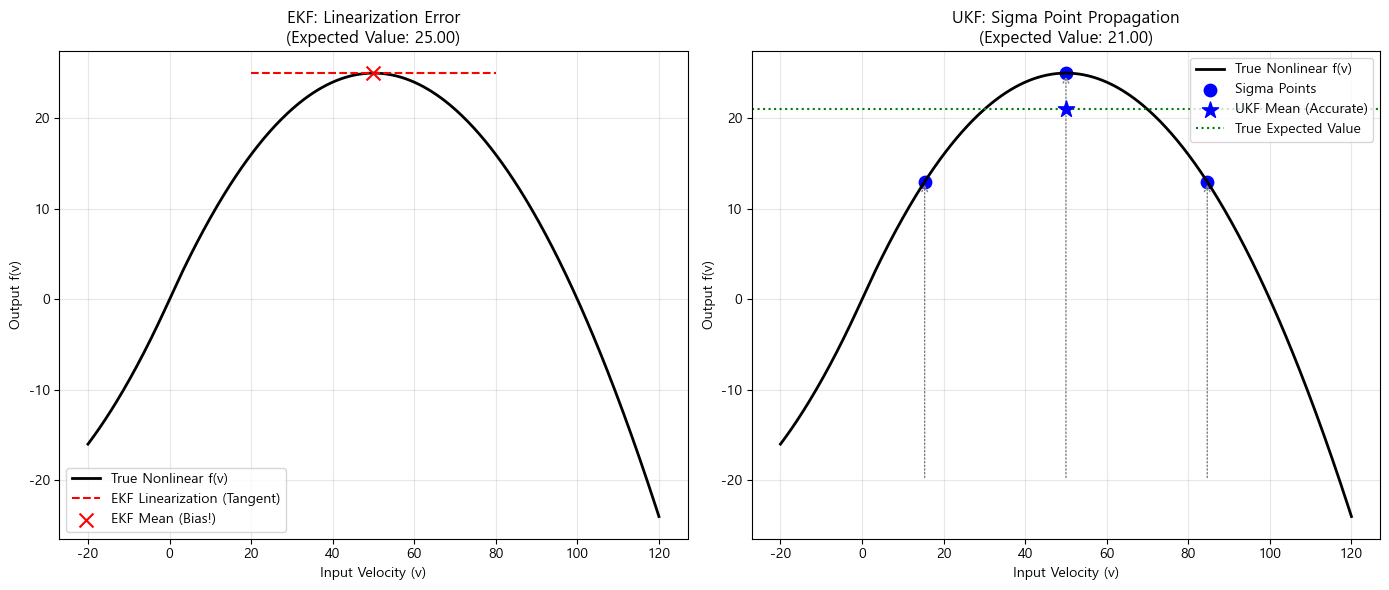

수치 분석 결과:
   1. 실제 기댓값 (수치적분): 21.0118
   2. UKF 추정 평균: 21.0000 (오차: 0.0118)
   3. EKF 추정 평균: 25.0000 (오차: 3.9882)


In [20]:
def visualize_unscented_transform():
    import scipy.stats as st
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    k = 0.01
    def drag_dynamics(v):
        return v - k * v * np.abs(v)

    # 설정: 평균 50, 표준편차 20 (분산 400)
    v_mean = 50
    v_std = 20
    v_var = v_std**2
    
    # ---------------------------------------------------------
    # [핵심] 수치적 정답 (True Expected Value) 계산
    # ---------------------------------------------------------
    # 가우시안 PDF를 가중치로 사용하여 E[f(v)] 계산
    v_samples = np.linspace(v_mean - 4*v_std, v_mean + 4*v_std, 1000)
    pdf_values = st.norm.pdf(v_samples, v_mean, v_std)
    true_expected_value = np.trapz(drag_dynamics(v_samples) * pdf_values, v_samples)

    # ---------------------------------------------------------
    # 1. EKF: 선형화 (Jacobian)
    # ---------------------------------------------------------
    v_plot = np.linspace(-20, 120, 500)
    axes[0].plot(v_plot, drag_dynamics(v_plot), 'k-', linewidth=2, label='True Nonlinear f(v)')
    
    # v=50에서의 자코비안 미분값
    f_v_mean = drag_dynamics(v_mean)
    df_dv = 1 - 2*k*v_mean # v>0 구간 미분
    
    # EKF는 평균을 단순히 함수에 넣음 (E[f(v)] ≈ f(E[v]))
    f_ekf_mean = f_v_mean
    
    v_lin = np.linspace(v_mean - 30, v_mean + 30, 100)
    axes[0].plot(v_lin, f_v_mean + df_dv * (v_lin - v_mean), 'r--', label='EKF Linearization (Tangent)')
    axes[0].scatter(v_mean, f_ekf_mean, color='red', marker='x', s=100, zorder=5, label='EKF Mean (Bias!)')
    
    axes[0].set_title(f"EKF: Linearization Error\n(Expected Value: {f_ekf_mean:.2f})")
    axes[0].legend()

    # ---------------------------------------------------------
    # 2. UKF: Unscented Transform (Alpha=1.0 for visualization)
    # ---------------------------------------------------------
    axes[1].plot(v_plot, drag_dynamics(v_plot), 'k-', linewidth=2, label='True Nonlinear f(v)')
    
    # 시각화를 위해 큰 alpha 사용 (시그마 포인트의 전파를 보여주기 위함)
    alpha_vis = 1.0 
    n = 1
    kappa = 2 # n+kappa=3 법칙 적용
    lamb = alpha_vis**2 * (n + kappa) - n
    
    # 시그마 포인트 생성
    spread = np.sqrt((n + lamb) * v_var)
    sigma_v = np.array([v_mean, v_mean + spread, v_mean - spread])
    sigma_f = drag_dynamics(sigma_v)
    
    # 가중치 계산
    w0_m = lamb / (n + lamb)
    wi_m = 1 / (2 * (n + lamb))
    weights_m = np.array([w0_m, wi_m, wi_m])
    
    # UKF 전파 평균 계산
    f_ukf_mean = np.dot(weights_m, sigma_f)
    
    # 플로팅
    axes[1].scatter(sigma_v, sigma_f, color='blue', s=80, label='Sigma Points')
    for sv, sf in zip(sigma_v, sigma_f):
        axes[1].annotate('', xy=(sv, sf), xytext=(sv, -20), 
                        arrowprops=dict(arrowstyle='->', color='gray', linestyle=':'))
    
    axes[1].scatter(v_mean, f_ukf_mean, color='blue', marker='*', s=150, zorder=5, label='UKF Mean (Accurate)')
    axes[1].axhline(true_expected_value, color='green', linestyle=':', label='True Expected Value')
    
    axes[1].set_title(f"UKF: Sigma Point Propagation\n(Expected Value: {f_ukf_mean:.2f})")
    axes[1].legend()

    for ax in axes:
        ax.grid(True, alpha=0.3)
        ax.set_xlabel("Input Velocity (v)")
        ax.set_ylabel("Output f(v)")

    plt.tight_layout()
    plt.show()

    print(f"수치 분석 결과:")
    print(f"   1. 실제 기댓값 (수치적분): {true_expected_value:.4f}")
    print(f"   2. UKF 추정 평균: {f_ukf_mean:.4f} (오차: {abs(f_ukf_mean - true_expected_value):.4f})")
    print(f"   3. EKF 추정 평균: {f_ekf_mean:.4f} (오차: {abs(f_ekf_mean - true_expected_value):.4f})")

visualize_unscented_transform()

In [22]:
x0 = np.array([0.0, 0.0]) 
P0 = np.diag([0.1, 0.1])
Q = np.diag([0.01, 1.0]) # 가속도 노이즈가 크므로 속도(v) 항의 Q를 키웁니다.
R = 1.5**2               # 기압계 노이즈 σ=1.5m
a_input = a_raw - 9.81

# 필터 인스턴스 생성 (이제 thrust_func 같은 인자는 필요 없습니다!)
ekf = EKF(x0, P0, Q, R)
ukf = UKF(x0, P0, Q, R, alpha=0.1)

ekf_res_list, ukf_res_list = [], []
ekf_P_list, ukf_P_list = [], []

print("필터 실행 중...")
for i in range(len(flight_data)):
    # u: 가속도 센서값 (중력이 보상된 'acceleration_noisy - 9.81')
    u = a_input[i] 
    # z: 기압 고도계 측정치
    z_m = z_obs[i]
    
    ekf.predict(u, dt)
    ekf.update(z_m)
    ekf_res_list.append(ekf.x.copy())
    ekf_P_list.append(ekf.P.copy())
    
    ukf.predict(u, dt)
    ukf.update(z_m)
    ukf_res_list.append(ukf.x.copy())
    ukf_P_list.append(ukf.P.copy())

# 5. 시각화용 넘파이 배열 변환
ekf_x = np.array(ekf_res_list)
ukf_x = np.array(ukf_res_list)
ekf_P = np.array(ekf_P_list)
ukf_P = np.array(ukf_P_list)
time = flight_data['time'].values

print("필터 실행 완료")

필터 실행 중...
필터 실행 완료


시각화 완료: ekf_ukf_comparison.png


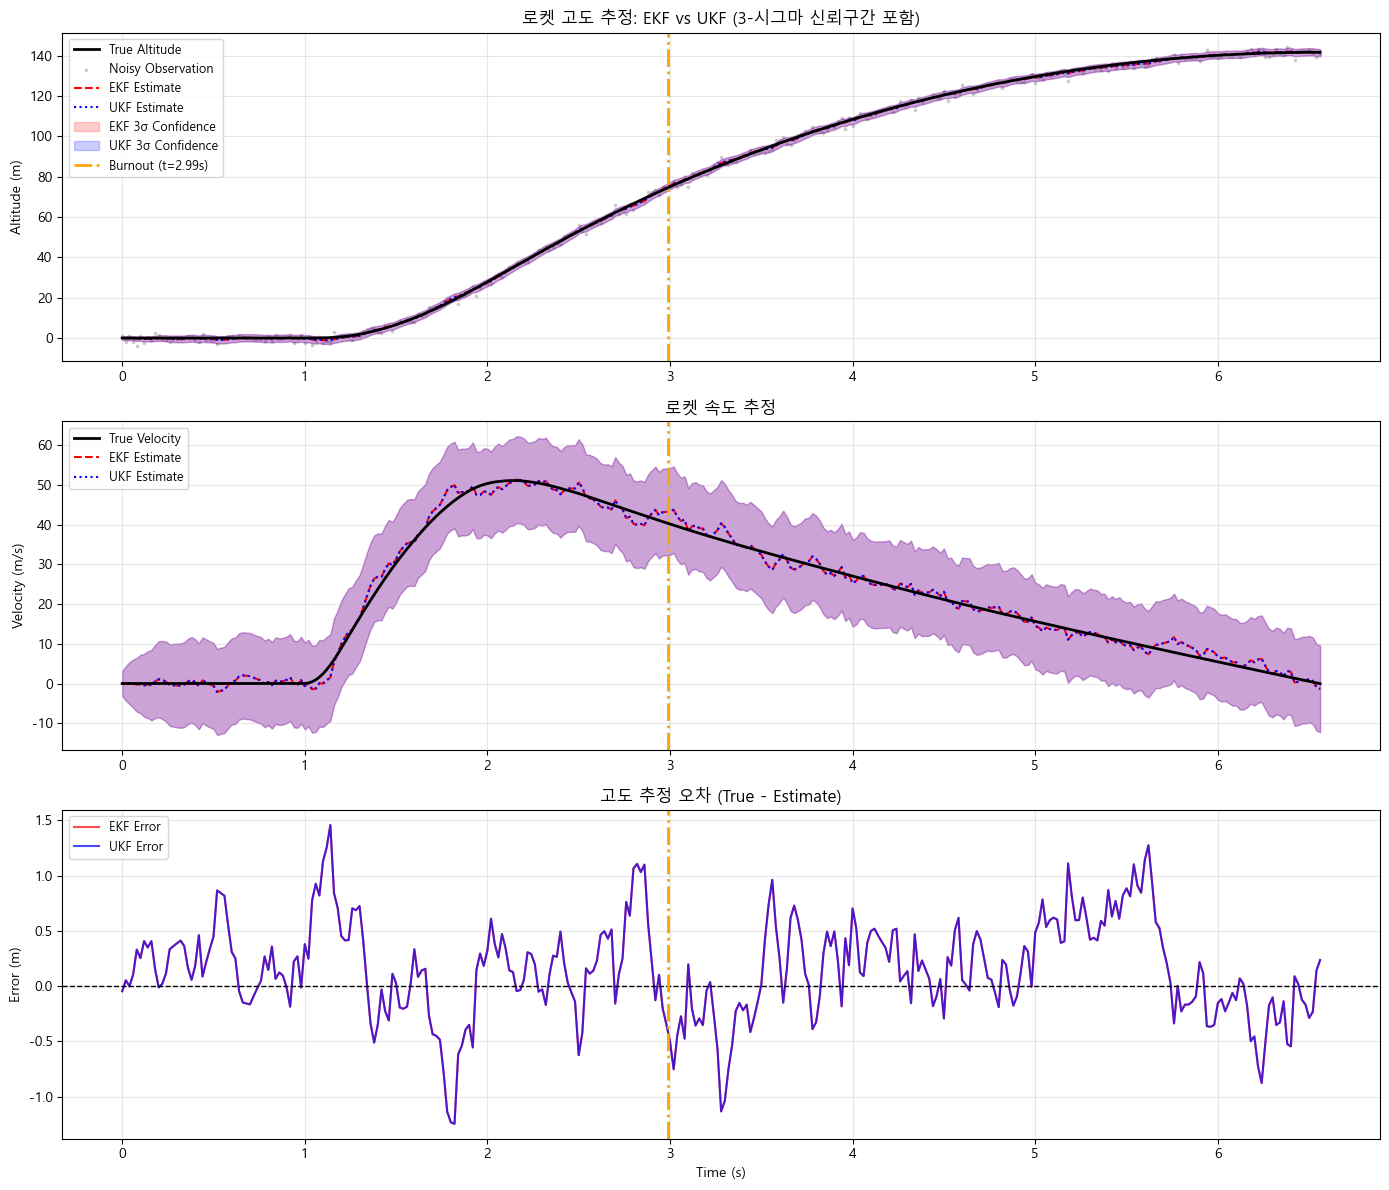

In [23]:
# ============================================================================
# [셀 7] 고도 추정 결과 시각화 (3-시그마 신뢰구간)
# ============================================================================
fig, axes = plt.subplots(3, 1, figsize=(14, 12))

# 1. 고도 추정 비교
ax1 = axes[0]
ax1.plot(time, z_true, 'k-', label='True Altitude', linewidth=2, zorder=10)
ax1.scatter(time, z_obs, s=3, c='gray', alpha=0.3, label='Noisy Observation', zorder=1)
ax1.plot(time, ekf_x[:, 0], 'r--', label='EKF Estimate', linewidth=1.5)
ax1.plot(time, ukf_x[:, 0], 'b:', label='UKF Estimate', linewidth=1.5)

# 3-시그마 신뢰구간 (Bella Lui 예제 참조)
ekf_sigma = 3 * np.sqrt(ekf_P[:, 0, 0])
ukf_sigma = 3 * np.sqrt(ukf_P[:, 0, 0])
ax1.fill_between(time, ekf_x[:, 0] - ekf_sigma, ekf_x[:, 0] + ekf_sigma, 
                 alpha=0.2, color='red', label='EKF 3σ Confidence')
ax1.fill_between(time, ukf_x[:, 0] - ukf_sigma, ukf_x[:, 0] + ukf_sigma, 
                 alpha=0.2, color='blue', label='UKF 3σ Confidence')

ax1.axvline(x=burnout_time, color='orange', linestyle='-.', linewidth=2, 
            label=f'Burnout (t={burnout_time:.2f}s)')
ax1.set_ylabel('Altitude (m)')
ax1.set_title('로켓 고도 추정: EKF vs UKF (3-시그마 신뢰구간 포함)')
ax1.legend(loc='upper left', fontsize=9)
ax1.grid(True, alpha=0.3)

# 2. 속도 추정 비교
ax2 = axes[1]
ax2.plot(time, v_true, 'k-', label='True Velocity', linewidth=2, zorder=10)
ax2.plot(time, ekf_x[:, 1], 'r--', label='EKF Estimate', linewidth=1.5)
ax2.plot(time, ukf_x[:, 1], 'b:', label='UKF Estimate', linewidth=1.5)

ekf_v_sigma = 3 * np.sqrt(ekf_P[:, 1, 1])
ukf_v_sigma = 3 * np.sqrt(ukf_P[:, 1, 1])
ax2.fill_between(time, ekf_x[:, 1] - ekf_v_sigma, ekf_x[:, 1] + ekf_v_sigma, 
                 alpha=0.2, color='red')
ax2.fill_between(time, ukf_x[:, 1] - ukf_v_sigma, ukf_x[:, 1] + ukf_v_sigma, 
                 alpha=0.2, color='blue')

ax2.axvline(x=burnout_time, color='orange', linestyle='-.', linewidth=2)
ax2.set_ylabel('Velocity (m/s)')
ax2.set_title('로켓 속도 추정')
ax2.legend(loc='upper left', fontsize=9)
ax2.grid(True, alpha=0.3)

# 3. 추정 오차 비교
ax3 = axes[2]
ekf_error = z_true - ekf_x[:, 0]
ukf_error = z_true - ukf_x[:, 0]
ax3.plot(time, ekf_error, 'r-', label='EKF Error', alpha=0.7)
ax3.plot(time, ukf_error, 'b-', label='UKF Error', alpha=0.7)
ax3.axhline(y=0, color='black', linestyle='--', linewidth=1)
ax3.axvline(x=burnout_time, color='orange', linestyle='-.', linewidth=2)
ax3.set_xlabel('Time (s)')
ax3.set_ylabel('Error (m)')
ax3.set_title('고도 추정 오차 (True - Estimate)')
ax3.legend(loc='upper left', fontsize=9)
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('./data/simulated/ekf_ukf_comparison.png', dpi=150)
print("시각화 완료: ekf_ukf_comparison.png")
plt.show()

In [24]:
# ============================================================================
# [셀 8] 정량적 성능 분석 (RMSE + 신뢰구간 검증)
# ============================================================================
# RMSE 계산
ekf_rmse = np.sqrt(np.mean((z_true - ekf_x[:, 0])**2))
ukf_rmse = np.sqrt(np.mean((z_true - ukf_x[:, 0])**2))

# 평균 절대 오차 (MAE)
ekf_mae = np.mean(np.abs(z_true - ekf_x[:, 0]))
ukf_mae = np.mean(np.abs(z_true - ukf_x[:, 0]))

# 최대 오차
ekf_max_err = np.max(np.abs(z_true - ekf_x[:, 0]))
ukf_max_err = np.max(np.abs(z_true - ukf_x[:, 0]))

# 3-시그마 신뢰구간 검증 (실제 값이 구간 안에 들어오는 비율)
ekf_in_bounds = np.mean((z_true >= ekf_x[:, 0] - ekf_sigma) & 
                        (z_true <= ekf_x[:, 0] + ekf_sigma)) * 100
ukf_in_bounds = np.mean((z_true >= ukf_x[:, 0] - ukf_sigma) & 
                        (z_true <= ukf_x[:, 0] + ukf_sigma)) * 100

# Bella Lui 예제 기준 (문서 11-12/15): 3-시그마 구간은 99.7% 포함 예상
print("=" * 70)
print("필터 성능 비교")
print("=" * 70)
print(f"\n[고도 추정 정확도]")
print(f"   EKF RMSE: {ekf_rmse:.4f} m")
print(f"   UKF RMSE: {ukf_rmse:.4f} m")
print(f"   개선율: {(1 - ukf_rmse/ekf_rmse) * 100:.1f}%")
print()
print(f"[평균 절대 오차 (MAE)]")
print(f"   EKF MAE: {ekf_mae:.4f} m")
print(f"   UKF MAE: {ukf_mae:.4f} m")
print()
print(f"[최대 오차]")
print(f"   EKF Max: {ekf_max_err:.4f} m")
print(f"   UKF Max: {ukf_max_err:.4f} m")
print()
print(f"[3-시그마 신뢰구간 검증]")
print(f"   EKF: {ekf_in_bounds:.1f}% (이론적: 99.7%)")
print(f"   UKF: {ukf_in_bounds:.1f}% (이론적: 99.7%)")
print()

# 판정
if ukf_rmse < ekf_rmse:
    print("UKF 가 EKF 보다 낮은 RMSE 를 보입니다 (비선형 구간 잘 처리)")
else:
    print("EKF 가 UKF 와 유사하거나 더 나은 성능을 보입니다 (선형 구간 우세)")

if 95 <= ekf_in_bounds <= 100 and 95 <= ukf_in_bounds <= 100:
    print("두 필터 모두 신뢰구간이 적절하게 설정되었습니다")
else:
    print("신뢰구간이 너무 좁거나 넓습니다 (Q, R 튜닝 필요)")

print("=" * 70)

필터 성능 비교

[고도 추정 정확도]
   EKF RMSE: 0.4683 m
   UKF RMSE: 0.4683 m
   개선율: -0.0%

[평균 절대 오차 (MAE)]
   EKF MAE: 0.3666 m
   UKF MAE: 0.3666 m

[최대 오차]
   EKF Max: 1.4569 m
   UKF Max: 1.4569 m

[3-시그마 신뢰구간 검증]
   EKF: 100.0% (이론적: 99.7%)
   UKF: 100.0% (이론적: 99.7%)

EKF 가 UKF 와 유사하거나 더 나은 성능을 보입니다 (선형 구간 우세)
두 필터 모두 신뢰구간이 적절하게 설정되었습니다


In [25]:
# ============================================================================
# [셀 9] 연소 구간별 성능 분석 (Bella Lui Burn out State 참조)
# ============================================================================
# 연소 중 vs 연소 후 분할
burning_mask = time <= burnout_time
coasting_mask = time > burnout_time

print("\n" + "=" * 70)
print("연소 구간별 성능 분석")
print("=" * 70)

# 연소 중
ekf_rmse_burning = np.sqrt(np.mean((z_true[burning_mask] - ekf_x[burning_mask, 0])**2))
ukf_rmse_burning = np.sqrt(np.mean((z_true[burning_mask] - ukf_x[burning_mask, 0])**2))

# 연소 후
ekf_rmse_coasting = np.sqrt(np.mean((z_true[coasting_mask] - ekf_x[coasting_mask, 0])**2))
ukf_rmse_coasting = np.sqrt(np.mean((z_true[coasting_mask] - ukf_x[coasting_mask, 0])**2))

print(f"\n[연소 중 (t ≤ {burnout_time:.2f}s)]")
print(f"   데이터 포인트: {np.sum(burning_mask)} 개")
print(f"   EKF RMSE: {ekf_rmse_burning:.4f} m")
print(f"   UKF RMSE: {ukf_rmse_burning:.4f} m")
print(f"   개선율: {(1 - ukf_rmse_burning/ekf_rmse_burning) * 100:.1f}%")
print()
print(f"[연소 후 (t > {burnout_time:.2f}s)]")
print(f"   데이터 포인트: {np.sum(coasting_mask)} 개")
print(f"   EKF RMSE: {ekf_rmse_coasting:.4f} m")
print(f"   UKF RMSE: {ukf_rmse_coasting:.4f} m")
print(f"   개선율: {(1 - ukf_rmse_coasting/ekf_rmse_coasting) * 100:.1f}%")
print()

# 분석
if ukf_rmse_burning < ekf_rmse_burning and ukf_rmse_coasting < ekf_rmse_coasting:
    print("UKF 가 연소/연소 후 모두에서 우세합니다 (비선형성 전반적 우위)")
elif ukf_rmse_burning < ekf_rmse_burning:
    print("UKF 가 연소 중 (고비선형) 구간에서 우세합니다")
else:
    print("EKF 가 연소 후 (저비선형) 구간에서 우세합니다 (연산량 고려 시 EKF 권장)")

print("=" * 70)


연소 구간별 성능 분석

[연소 중 (t ≤ 2.99s)]
   데이터 포인트: 150 개
   EKF RMSE: 0.4725 m
   UKF RMSE: 0.4725 m
   개선율: 0.0%

[연소 후 (t > 2.99s)]
   데이터 포인트: 179 개
   EKF RMSE: 0.4648 m
   UKF RMSE: 0.4648 m
   개선율: -0.0%

UKF 가 연소 중 (고비선형) 구간에서 우세합니다


다중 비행 검증
다중 비행 검증 완료: multiflight_validation.png


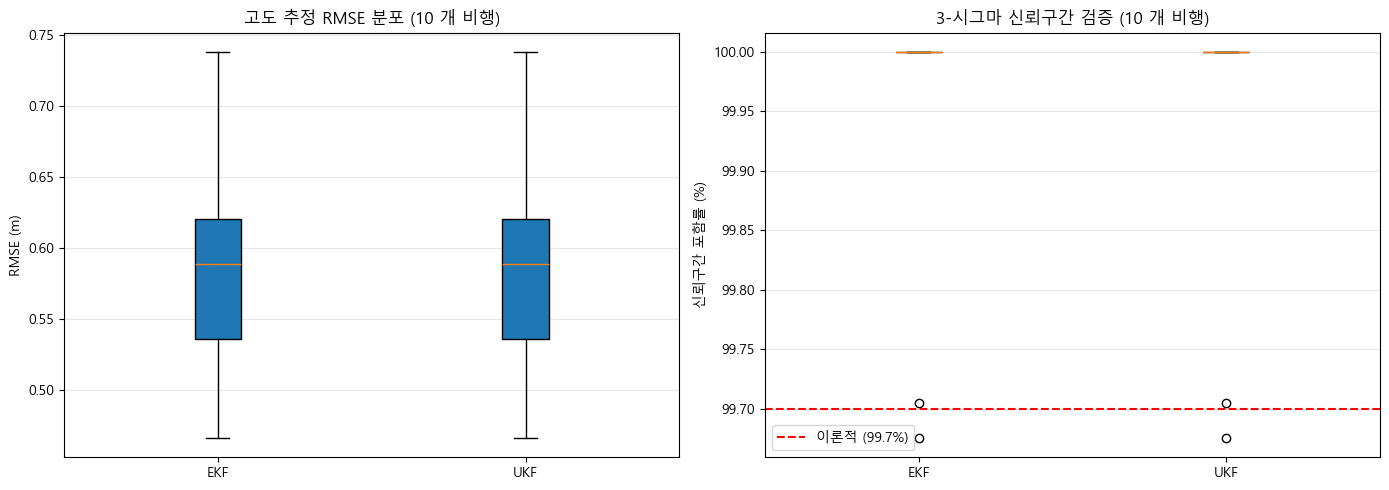


다중 비행 검증 통계 (10 개 비행)

[RMSE]
   EKF: 평균 0.5861 m, 표준편차 0.0711 m
   UKF: 평균 0.5861 m, 표준편차 0.0711 m
   개선율: 0.0%

[신뢰구간 포함률]
   EKF: 평균 99.9%, 표준편차 0.1%
   UKF: 평균 99.9%, 표준편차 0.1%


In [26]:
def evaluate_filter_on_flights(df, df_meta, filter_class, n_flights=10, **filter_kwargs):
    """
    여러 비행에 대해 필터 성능 평가 (IMU 기반 Kinematic 모델 대응 버전)
    """
    rmse_list = []
    in_bounds_list = []
    
    # 실제 데이터에 존재하는 ID들 추출
    available_ids = df['flight_id'].unique()
    flight_ids = available_ids[:min(n_flights, len(available_ids))]
    
    for fid in flight_ids:
        # 1. 해당 비행 데이터 필터링
        flight_data = df[df['flight_id'] == fid].reset_index(drop=True)
        
        # 2. 데이터 준비 (Relative Altitude & Kinematic Acceleration)
        z_origin = flight_data['altitude'].iloc[0]
        z_true = flight_data['altitude'].values - z_origin
        
        # 필터 입력값 준비
        z_obs_all = flight_data['altitude_noisy'].values - z_origin
        a_input_all = flight_data['acceleration_noisy'].values # Raw IMU (a+g)
        
        dt = 0.02
        
        # 3. 필터 초기화 (인자명 매칭: 오직 x0, P0, Q, R만 전달)
        x0 = np.array([z_obs_all[0], 0.0])
        P0 = np.diag([1.0, 1.0])
        Q = np.diag([0.01, 1.0]) # 속도 불확실성 넉넉히
        R = 1.5**2               # 기압계 노이즈
        
        # [수정 포인트] 불필요한 rho, Cd, m_init 등을 제거하고 생성
        filt = filter_class(x0, P0, Q, R, **filter_kwargs)
        
        # 4. 필터 실행 및 이력 저장
        x_history = []
        P_history = []
        
        for i in range(len(flight_data)):
            u = a_input_all[i]
            z_m = z_obs_all[i]
            
            filt.predict(u, dt)
            filt.update(z_m)
            
            x_history.append(filt.x.copy())
            P_history.append(filt.P.copy())
            
        x_hist = np.array(x_history)
        P_hist = np.array(P_history)
        
        # 5. RMSE 계산 (고도 기준)
        rmse = np.sqrt(np.mean((z_true - x_hist[:, 0])**2))
        rmse_list.append(rmse)
        
        # 6. 신뢰구간 검증 (3-sigma)
        sigma = 3 * np.sqrt(P_hist[:, 0, 0])
        in_bounds = np.mean((z_true >= x_hist[:, 0] - sigma) & 
                           (z_true <= x_hist[:, 0] + sigma)) * 100
        in_bounds_list.append(in_bounds)
    
    return rmse_list, in_bounds_list

# ============================================================================
# 실행 부분
# ============================================================================
print("다중 비행 검증")

# EKF 실행
ekf_rmse_list, ekf_bounds_list = evaluate_filter_on_flights(df, df_meta, EKF, n_flights=10)

# UKF 실행 (alpha 등 UKF 전용 파라미터만 전달)
ukf_rmse_list, ukf_bounds_list = evaluate_filter_on_flights(df, df_meta, UKF, n_flights=10, alpha=0.1)

# 결과 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# RMSE 분포
axes[0].boxplot([ekf_rmse_list, ukf_rmse_list], labels=['EKF', 'UKF'], patch_artist=True)
axes[0].set_ylabel('RMSE (m)')
axes[0].set_title('고도 추정 RMSE 분포 (10 개 비행)')
axes[0].grid(True, alpha=0.3, axis='y')

# 신뢰구간 포함률
axes[1].boxplot([ekf_bounds_list, ukf_bounds_list], labels=['EKF', 'UKF'], patch_artist=True)
axes[1].axhline(y=99.7, color='red', linestyle='--', label='이론적 (99.7%)')
axes[1].set_ylabel('신뢰구간 포함률 (%)')
axes[1].set_title('3-시그마 신뢰구간 검증 (10 개 비행)')
axes[1].grid(True, alpha=0.3, axis='y')
axes[1].legend()

plt.tight_layout()
plt.savefig('./data/simulated/multiflight_validation.png', dpi=150)
print("다중 비행 검증 완료: multiflight_validation.png")
plt.show()

# 통계 출력
print("\n" + "=" * 70)
print("다중 비행 검증 통계 (10 개 비행)")
print("=" * 70)
print(f"\n[RMSE]")
print(f"   EKF: 평균 {np.mean(ekf_rmse_list):.4f} m, 표준편차 {np.std(ekf_rmse_list):.4f} m")
print(f"   UKF: 평균 {np.mean(ukf_rmse_list):.4f} m, 표준편차 {np.std(ukf_rmse_list):.4f} m")
print(f"   개선율: {(1 - np.mean(ukf_rmse_list)/np.mean(ekf_rmse_list)) * 100:.1f}%")
print()
print(f"[신뢰구간 포함률]")
print(f"   EKF: 평균 {np.mean(ekf_bounds_list):.1f}%, 표준편차 {np.std(ekf_bounds_list):.1f}%")
print(f"   UKF: 평균 {np.mean(ukf_bounds_list):.1f}%, 표준편차 {np.std(ukf_bounds_list):.1f}%")
print("=" * 70)